In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2


# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.plotting_fns import PlottingFns
from stericheight.data_handler import GEBCO
from stericheight.utils import Utils
from load_meop import MEOP
from region import Region
from functions import Functions
from OceanDataStore import OceanDataCatalog


pfns = PlottingFns()
fns = Functions()


In [3]:
import gsw
import cartopy
import cmocean
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import xesmf as xe
import warnings

fname_zhou = '../data/CLIM_3D_forJenny.nc'
fname_spira = '../data/qc_profile_ds_2dbar.nc'
fname_glorys1 = '../data/GLORYS/glorys_001.nc'
fname_glorys2 = '../data/GLORYS/glorys_002.nc'

In [4]:
extent = [138, 150,-68,-64]
extent2 = [139,142,-67,-66]
profiles = pickle.load(open('c3data.pkl','rb'))

In [5]:
profiles_shelf = profiles.where(profiles.elevation > -1000,drop=True
                                ).sortby('lat').sel(lat=slice(extent2[2],extent2[3])
                                ).sortby('lon').sel(lon=slice(extent2[0],extent2[1])
                                ).sortby('time')

In [6]:
t1 = profiles_shelf.time.min()
t2 = profiles_shelf.time.max()

In [18]:
# glorys first. need to interpolate before loading out of dask
ds1 = xr.open_dataset(fname_glorys1)
ds2 = xr.open_dataset(fname_glorys2)
glorys = xr.merge([ds1,ds2]).sel(time=slice(t1,t2))
glorys_shelf = glorys.sel(latitude=slice(extent2[2],extent2[3])).sel(longitude=slice(extent2[0],extent2[1])).where(glorys.depth<1000,drop=True)

glorys_shelf['pres'] = gsw.conversions.p_from_z(-glorys_shelf.depth,glorys_shelf.latitude.mean())

glorys_shelf_forinterp = glorys_shelf.rename({
    "latitude": "lat",
    "longitude": "lon"
}).swap_dims({'depth':'pres'}).drop('depth')

glorys_shelf_forinterp.to_netcdf('glorys_shelf_forinterp.nc')

/tmp/ipykernel_4079818/1683180466.py:4: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'depth' ('depth',) The recommendation is to set join explicitly for this case.
  glorys = xr.merge([ds1,ds2]).sel(time=slice(t1,t2))
/tmp/ipykernel_4079818/1683180466.py:12: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  }).swap_dims({'depth':'pres'}).drop('depth')


In [12]:
# load nemo data
catalog = OceanDataCatalog(catalog_name="noc-model-stac")
nemo = catalog.open_dataset(id='noc-npd-era5/npd-eorca12-era5v1/gn/T1m_4d',variable_names=['thetao_con','so_abs'])

# prepare nemo
# crop to region
lats = nemo.nav_lat.load()
lons = nemo.nav_lon.load()
depth = nemo.deptht.load()
mask = (lats >= extent2[2]) & (lats <= extent2[3]) & (lons >= extent2[0]) & (lons <= extent2[1]) & (depth < 1000)
nemo_shelf = nemo.where(mask,drop=True)
# make monthly
nemo_shelf=nemo_shelf.resample({'time_counter':'MS'}).mean().sel(time_counter=slice(t1,t2))
nemo_shelf['pres'] = gsw.conversions.p_from_z(-nemo_shelf.deptht,nemo_shelf.nav_lat.mean())

nemo_shelf_forinterp = nemo_shelf.rename({
    "time_counter":"time",
    "nav_lat": "lat",
    "nav_lon": "lon"
}).swap_dims({'deptht':'pres'}).drop('deptht')

nemo_shelf_forinterp.to_netcdf('nemo_shelf_forinterp.nc')

  2026-04-02T14:50:35.205342Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: timeout: client error (Connect): HTTP connect timeout occurred after 1s: timed out (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Timeout, source: hyper_util::client::legacy::Error(Connect, HttpTimeoutError { kind: "HTTP connect", duration: 1s }), connection: Unknown } }) }))
    at /root/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-config-1.8.12/src/imds/region.rs:66



/tmp/ipykernel_4079818/1969150097.py:20: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  }).swap_dims({'deptht':'pres'}).drop('deptht')


In [ ]:
glorys_shelf_forinterp = xr.open_dataset('glorys_shelf_forinterp.nc')
nemo_shelf_forinterp=xr.open_dataset('nemo_shelf_forinterp.nc')

In [ ]:
# chunk for speed
glorys_shelf_forinterp = glorys_shelf_forinterp.chunk({
    "time": 10,
    "lat": 50,
    "lon": 50,
    "pres": 42   # full depth is fine
})

# chunk for speed
nemo_shelf_rename = nemo_shelf_forinterp.chunk({
    "time": 10,
    "y": 50,
    "x": 50,
    "pres": 42   # full depth is fine
})

profiles_shelf = profiles_shelf.chunk({"time": 200})

In [ ]:
thetao_interp = glorys_shelf_forinterp.thetao.interp(time=profiles_shelf.time.data,
                                                     pres=profiles_shelf.pres.data,
                                                     lat=("time",profiles_shelf.lat.data),
                                                     lon=("time",profiles_shelf.lon.data),
                                                     
                                                     method='linear')
so_interp = glorys_shelf_forinterp.so.interp(time=profiles_shelf.time.data,
                                             pres=profiles_shelf.pres.data,
                                             lat=("time",profiles_shelf.lat.data),
                                             lon=("time",profiles_shelf.lon.data),
                                             method='linear')

/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/dask/array/gufunc.py:477: PerformanceWarning: Increasing number of chunks by factor of 64
  tmp = blockwise(
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/dask/array/gufunc.py:477: PerformanceWarning: Increasing number of chunks by factor of 64
  tmp = blockwise(


In [ ]:
# nemo is curvilinear so do time first
nemo_shelf_tinterp = nemo_shelf_rename.interp(time=profiles_shelf.time, method="linear")

# then lat and lon
ds_in = xr.Dataset({
    "lat": (("y", "x"), nemo_shelf_tinterp.lat.data),
    "lon": (("y", "x"), nemo_shelf_tinterp.lon.data),
})

ds_out = xr.Dataset({
    "lat": ("points", profiles_shelf.lat.data),
    "lon": ("points", profiles_shelf.lon.data)
})

regridder = xe.Regridder(ds_in, ds_out, "bilinear",locstream_out=True)

nemo_regridded = regridder(nemo_shelf_tinterp)

# rejig lat and lon and interp depth
nemo_interp = (
    nemo_regridded
    .assign_coords({
        "time": profiles_shelf.time,
        "lat": ("time", profiles_shelf.lat.data),
        "lon": ("time", profiles_shelf.lon.data),
    })
)
nemo_interp2=nemo_interp.isel(points=xr.DataArray(
    np.arange(len(nemo_interp.time)),
    dims="time"
)).interp(pres=profiles_shelf.pres,method='linear')

/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/computation/apply_ufunc.py:452: PerformanceWarning: Regridding is increasing the number of chunks by a factor of 116.0, you might want to specify sizes in `output_chunks` in the regridder call. Default behaviour is to preserve the chunk sizes from the input (10, 13).
  result_vars[name] = func(*variable_args)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/computation/apply_ufunc.py:452: PerformanceWarning: Regridding is increasing the number of chunks by a factor of 116.0, you might want to specify sizes in `output_chunks` in the regridder call. Default behaviour is to preserve the chunk sizes from the input (10, 13).
  result_vars[name] = func(*variable_args)


In [ ]:
profiles_shelf_ts = profiles_shelf.expand_dims({'source':['Observations']}).drop(['n_prof','dsource','mld','temp','psal','rho','mlp','profile_code','gph','elevation','month','year'])
glorys_shelf_ts = xr.Dataset({'ctemp':thetao_interp, 'asal': so_interp}).expand_dims({'source':['GLORYS']})
nemo_shelf_ts = nemo_interp2.rename({'thetao_con':'ctemp','so_abs':'asal'}).expand_dims({'source':['NEMO']})

/tmp/ipykernel_4079818/4144214414.py:1: FutureWarning: dropping variables using `drop` is deprecated; use drop_vars.
  profiles_shelf_ts = profiles_shelf.expand_dims({'source':['Observations']}).drop(['n_prof','dsource','mld','temp','psal','rho','mlp','profile_code','gph','elevation','month','year'])


In [ ]:
pgn = xr.concat([profiles_shelf_ts,glorys_shelf_ts,nemo_shelf_ts],dim='source')

<xarray.Dataset> Size: 36MB
Dimensions:     (source: 3, time: 1502, pres: 501)
Coordinates:
  * source      (source) object 24B 'Observations' 'GLORYS' 'NEMO'
  * time        (time) datetime64[ns] 12kB 2007-02-20T23:29:59.000002 ... 202...
    lon         (time) float64 12kB dask.array<chunksize=(200,), meta=np.ndarray>
    lat         (time) float64 12kB dask.array<chunksize=(200,), meta=np.ndarray>
    n_prof      (time) float64 12kB dask.array<chunksize=(200,), meta=np.ndarray>
  * pres        (pres) int64 4kB 0 2 4 6 8 10 12 ... 990 992 994 996 998 1000
Data variables:
    asal        (source, time, pres) float32 9MB dask.array<chunksize=(1, 200, 501), meta=np.ndarray>
    ctemp       (source, time, pres) float32 9MB dask.array<chunksize=(1, 200, 501), meta=np.ndarray>
    thetao_con  (source, time, pres) float32 9MB dask.array<chunksize=(1, 376, 501), meta=np.ndarray>
    so_abs      (source, time, pres) float32 9MB dask.array<chunksize=(1, 376, 501), meta=np.ndarray>
Attributes:
    description:  Interpolated dataset from 2004 to 2021. Contains MLD from p...

In [ ]:
pgn.load()

<xarray.Dataset> Size: 63MB
Dimensions:        (time: 1502, pres: 501)
Coordinates:
  * time           (time) datetime64[ns] 12kB 2007-02-20T23:29:59.000002 ... ...
    lon            (time) float64 12kB 140.0 140.0 140.0 ... 140.0 139.8 139.8
    lat            (time) float64 12kB -66.56 -66.58 -66.66 ... -66.61 -66.61
    n_prof         (time) float64 12kB 7.932e+05 7.932e+05 7.932e+05 ... nan nan
  * pres           (pres) int64 4kB 0 2 4 6 8 10 12 ... 990 992 994 996 998 1000
Data variables: (12/17)
    temp           (time, pres) float64 6MB nan nan nan -1.339 ... nan nan nan
    psal           (time, pres) float64 6MB nan nan nan 33.86 ... nan nan nan
    dsource        (time, pres) object 6MB 'MEOP' 'MEOP' ... 'MEOP-' 'MEOP-'
    mld            (time) float64 12kB 65.34 17.82 49.5 49.5 ... nan nan nan nan
    asal           (time, pres) float32 3MB nan nan nan 34.02 ... nan nan nan
    ctemp          (time, pres) float32 3MB nan nan nan -1.335 ... nan nan nan
    ...             ...
    month          (time) float64 12kB 2.0 2.0 2.0 2.0 2.0 ... 2.0 2.0 2.0 2.0
    year           (time) float64 12kB 2.007e+03 2.007e+03 ... 2.024e+03
    glorys_thetao  (time, pres) float64 6MB nan nan nan nan ... nan nan nan nan
    glorys_so      (time, pres) float64 6MB nan nan nan nan ... nan nan nan nan
    nemo_thetao    (time, pres) float64 6MB nan nan nan nan ... nan nan nan nan
    nemo_so        (time, pres) float64 6MB nan nan nan nan ... nan nan nan nan
Attributes:
    description:  Interpolated dataset from 2004 to 2021. Contains MLD from p...

In [ ]:
pgn.to_netcdf('pgn.nc')

/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3699: SerializationWarning: saving variable n_prof with floating point data as an integer dtype without any _FillValue to use for NaNs
  exec(code_obj, self.user_global_ns, self.user_ns)
/home/users/eejco/miniforge3/envs/nemo-env3/lib/python3.14/site-packages/xarray/core/duck_array_ops.py:264: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


[None, None, None]

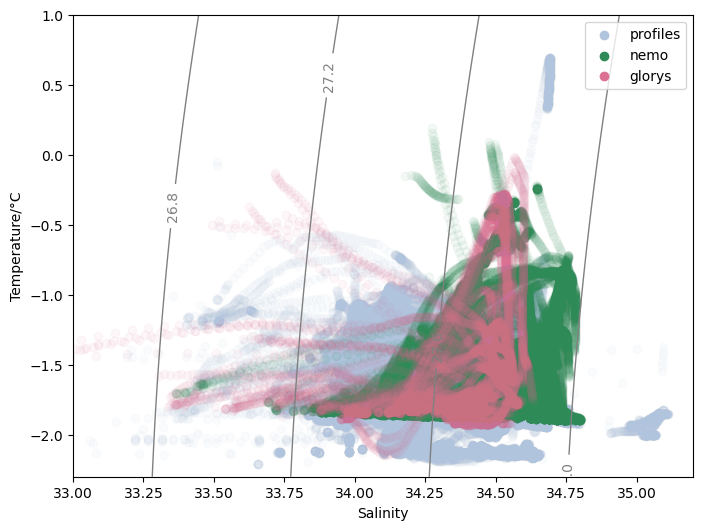

In [106]:
fig, ax = plt.subplots(1,1,figsize=(8,6))
alpha=0.05
ims = []
# shapes=['o','s','*','D']
# for s,c in zip(seasons,shapes):
ims.append(ax.scatter(pgn.psal,pgn.temp,alpha=alpha,c='lightsteelblue',label='profiles'))
ims.append(ax.scatter(pgn.nemo_so,pgn.nemo_thetao,alpha=alpha,c='seagreen',label='nemo'))
ims.append(ax.scatter(pgn.glorys_so,pgn.glorys_thetao,alpha=alpha,c='palevioletred',label='glorys'))
#im=ax.scatter(en4_interp.salinity,en4_interp.temperature,alpha=0.005,c='slateblue',marker='o')


tlim=[-2.3,1]
slim=[33,35.2]
temprange,psalrange,sig0range_ = fns.sig0range(tlim,slim)
cs=ax.contour(psalrange,temprange,sig0range_,levels=4,colors='grey',linewidths=1)
plt.clabel(cs, fontsize=10, inline=1, fmt='%0.1f')
ax.set_xlim(slim)
ax.set_ylim(tlim)
ax.set_ylabel('Temperature/°C')
ax.set_xlabel('Salinity')

[im.set_alpha(1) for im in ims]
ax.legend()
[im.set_alpha(alpha) for im in ims]

In [109]:
def get_depthclass(z):
    if z < 100:
        return '0-100dbar'
    elif z < 300:
        return '100-300dbar'
    else:
        return '300-600dbar'
pgn['depthclass'] = xr.DataArray([get_depthclass(z) for z in pgn.pres.data],coords={'pres':pgn.pres})

In [ ]:
pgn_df = pgn.to_dataframe().reset_index()
sns.boxplot(data=temp, x="class", y="age", hue="alive")

,time,pres,temp,psal,dsource,mld,asal,ctemp,rho,mlp,...,month,year,lon,lat,n_prof,glorys_thetao,glorys_so,nemo_thetao,nemo_so,depthclass
0,2007-02-20 23:29:59.000002,0,NaN,NaN,MEOP,65.335625,NaN,NaN,NaN,52.0,...,2.0,2007.0,140.042,-66.5560,793190.0,NaN,NaN,NaN,NaN,0-100dbar
1,2007-02-20 23:29:59.000002,2,NaN,NaN,MEOP,65.335625,NaN,NaN,NaN,52.0,...,2.0,2007.0,140.042,-66.5560,793190.0,NaN,NaN,NaN,NaN,0-100dbar
2,2007-02-20 23:29:59.000002,4,NaN,NaN,MEOP,65.335625,NaN,NaN,NaN,52.0,...,2.0,2007.0,140.042,-66.5560,793190.0,NaN,NaN,NaN,NaN,0-100dbar
3,2007-02-20 23:29:59.000002,6,-1.339080,33.857399,MEOP,65.335625,34.020248,-1.334713,1027.243896,52.0,...,2.0,2007.0,140.042,-66.5560,793190.0,NaN,NaN,NaN,NaN,0-100dbar
4,2007-02-20 23:29:59.000002,8,-1.334258,33.858277,MEOP,65.335625,34.021130,-1.329891,1027.244507,52.0,...,2.0,2007.0,140.042,-66.5560,793190.0,NaN,NaN,NaN,NaN,0-100dbar
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
752497,2024-02-18 20:49:59.000000,992,NaN,NaN,MEOP-,NaN,NaN,NaN,NaN,NaN,...,2.0,2024.0,139.811,-66.6133,NaN,NaN,NaN,NaN,NaN,300-600dbar
752498,2024-02-18 20:49:59.000000,994,NaN,NaN,MEOP-,NaN,NaN,NaN,NaN,NaN,...,2.0,2024.0,139.811,-66.6133,NaN,NaN,NaN,NaN,NaN,300-600dbar
752499,2024-02-18 20:49:59.000000,996,NaN,NaN,MEOP-,NaN,NaN,NaN,NaN,NaN,...,2.0,2024.0,139.811,-66.6133,NaN,NaN,NaN,NaN,NaN,300-600dbar
752500,2024-02-18 20:49:59.000000,998,NaN,NaN,MEOP-,NaN,NaN,NaN,NaN,NaN,...,2.0,2024.0,139.811,-66.6133,NaN,NaN,NaN,NaN,NaN,300-600dbar
